In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_copy import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jnp.ravel(x)
        x = jax.nn.tanh(self.layer1(x))
        x = self.layer2(x)
        return x   # shape (3,)
    

class Example(TripletModel):
    # internal unconstrained parameters for a 2x2 lower-triangular factor
    # not the physical [k_ss, k_sb, k_bb] directly
    K: jax.Array
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        """
        der_K is the user-facing 3-vector:
            [diag_stretching, offdiag_stretch_bend, diag_bending]
          = [k_ss, k_sb, k_bb]

        This is converted internally to parameters of a Cholesky factor so that
        the resulting stiffness is symmetric PSD.
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # PSD check for the structured matrix
        # In the symmetric-stretch / bending basis, the 2x2 block is:
        # [[k_ss, sqrt(2) k_sb],
        #  [sqrt(2) k_sb, k_bb]]
        #
        # So PSD requires:
        #   k_ss >= 0
        #   k_bb >= 0
        #   k_ss * k_bb - 2 * k_sb^2 >= 0
        if (k_ss0 < 0) or (k_bb0 < 0) or (k_ss0 * k_bb0 - 2.0 * k_sb0**2 < 0):
            raise ValueError(
                "Initial [k_ss, k_sb, k_bb] must satisfy PSD condition: "
                "k_ss >= 0, k_bb >= 0, and k_ss*k_bb - 2*k_sb^2 >= 0."
            )

        # Convert desired physical entries to a 2x2 Cholesky factor
        l11 = jnp.sqrt(jnp.maximum(k_ss0, eps))
        l21 = jnp.sqrt(2.0) * k_sb0 / l11
        rem = k_bb0 - l21**2
        l22 = jnp.sqrt(jnp.maximum(rem, eps))

        # Store unconstrained parameters so diagonals can be enforced positive via softplus
        p0 = inv_softplus(l11 - eps)
        p1 = l21
        p2 = inv_softplus(l22 - eps)

        self.K = jnp.array([p0, p1, p2])
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=3, key=key)

    def _vec_to_L(self, p: jax.Array) -> jax.Array:
        eps = 1e-6
        p = jnp.ravel(p)
        return jnp.array([
            [jax.nn.softplus(p[0]) + eps, 0.0],
            [p[1],                        jax.nn.softplus(p[2]) + eps],
        ])

    def get_K_entries(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3"]:
        """
        Returns the physical structured coefficients:
            [k_ss, k_sb, k_bb]
        where the energy is

            0.5*k_ss*(e0^2 + e1^2) + k_sb*(e0 + e1)*eb + 0.5*k_bb*eb^2
        """
        del_strain = jnp.ravel(del_strain)

        # small learned correction in parameter space for stability
        dp = 1e-2 * self.mlp(del_strain)
        p = self.K + dp

        L = self._vec_to_L(p)
        B = L @ L.T
        # B is the PSD 2x2 block in [symmetric-stretch, bending] basis:
        # B = [[k_ss, sqrt(2) k_sb],
        #      [sqrt(2) k_sb, k_bb]]

        k_ss = B[0, 0]
        k_sb = B[0, 1] / jnp.sqrt(2.0)
        k_bb = B[1, 1]

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3 3"]:
        """
        Full structured stiffness matrix acting on [e0, e1, eb]:
            [[k_ss,   0,   k_sb],
             [  0,  k_ss,  k_sb],
             [k_sb, k_sb,  k_bb]]
        """
        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [3]:
from util import TestCase

train_file = "output.npz"
valid_file = "output_valid.npz"

# train_file = "output_valid.npz"
# valid_file = "output.npz"

# validate_model(Example)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=jnp.array([2, 0.01, 0.02]) )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.get_K_entries(jnp.zeros(5)) )

Step 0    | LR: 1.000e-02  | Train: 4.90670e-05  | Valid: 1.90800e-04  | K: [ 1.98308638e+00 -1.48926604e-03  2.03638522e-02]
Step 10   | LR: 9.991e-03  | Train: 3.65942e-05  | Valid: 2.04138e-04  | K: [ 1.88752488e+00 -1.45134412e-03  2.44024483e-02]
Step 20   | LR: 9.965e-03  | Train: 3.10365e-05  | Valid: 1.93975e-04  | K: [1.76787594 0.00691682 0.02915588]
Step 30   | LR: 9.921e-03  | Train: 2.34441e-05  | Valid: 1.14420e-04  | K: [1.66500053 0.03183313 0.03640327]
Step 40   | LR: 9.859e-03  | Train: 1.43467e-05  | Valid: 7.01798e-05  | K: [1.54819058 0.04547565 0.04483838]
Step 50   | LR: 9.781e-03  | Train: 5.97325e-06  | Valid: 2.73539e-05  | K: [1.44938139 0.05987535 0.0547352 ]
Step 60   | LR: 9.685e-03  | Train: 1.19356e-06  | Valid: 4.96827e-06  | K: [1.37706424 0.0723142  0.0645196 ]
Step 70   | LR: 9.573e-03  | Train: 2.62222e-07  | Valid: 1.04031e-07  | K: [1.33562342 0.08059307 0.07151861]
Step 80   | LR: 9.446e-03  | Train: 3.07539e-07  | Valid: 2.82887e-07  | K: [1.321

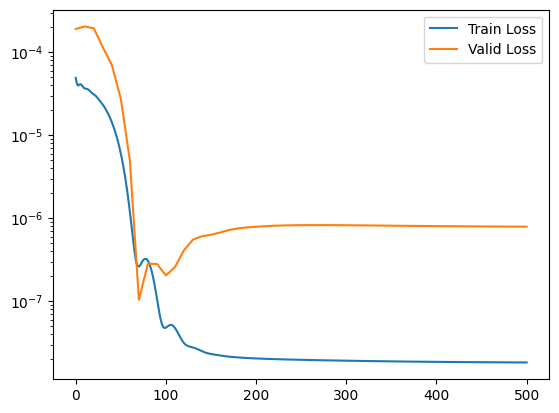

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
train = TestCase.from_npz(train_file)
valid = TestCase.from_npz(valid_file)
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[0])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[0.  0.  0.  0.  0.  0.5 0.  0. ]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.   0.   0.   0.   0.  -0.1  0.   0. ]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [6]:

base, aux, _, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [7]:
animate(valid.qs)

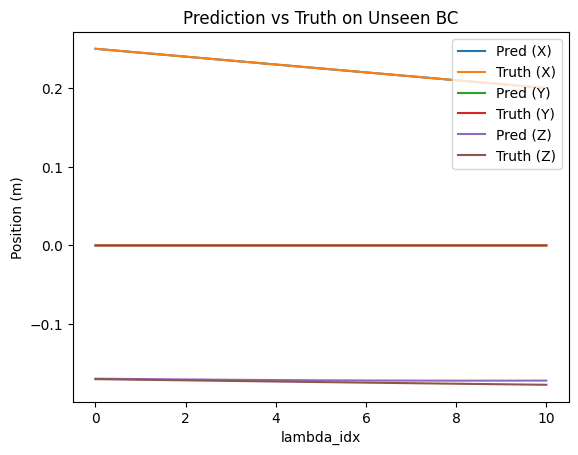

In [8]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
plt.plot(pred[:, 5], label="Pred (Y)")
plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.xlabel("lambda_idx")
plt.ylabel("Position (m)")
plt.show()

In [9]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.5 0.  0. ]
final:  [1. 0. 0.]
Validation BC:
init:  [0.5 0.  0. ]
final:  [0.4 0.  0. ]


In [10]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the training data:  [ 4.99999146e-01 -9.07533152e-06 -1.23843111e-01]


In [11]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the validation data:  [ 2.00012391e-01  5.71156971e-06 -1.77130449e-01]


In [12]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [ 2.49996607e-01 -4.86757103e-06 -1.69368745e-01]
final position of the middle node in the prediction:  [ 1.99998307e-01 -4.85622992e-07 -1.71818808e-01]
